# Predicting Restaurant Tips Task
**Objective:** Build Machine Learning models (Linear, Ridge, Lasso) to predict tips based on restaurant data.

In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Load data
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## 1. Exploratory Data Analysis (EDA)

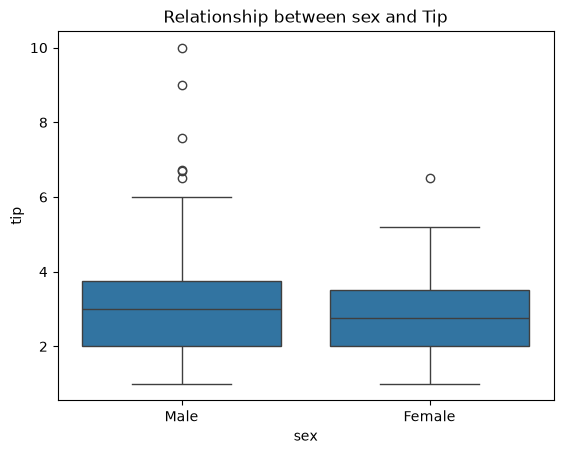

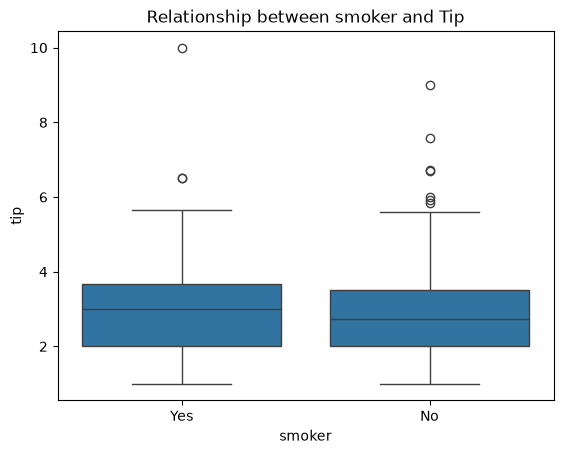

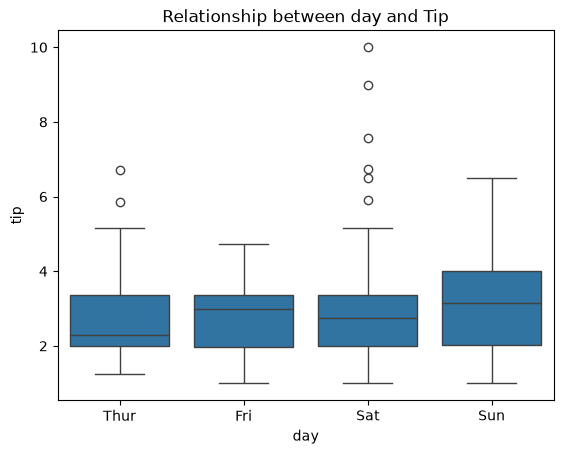

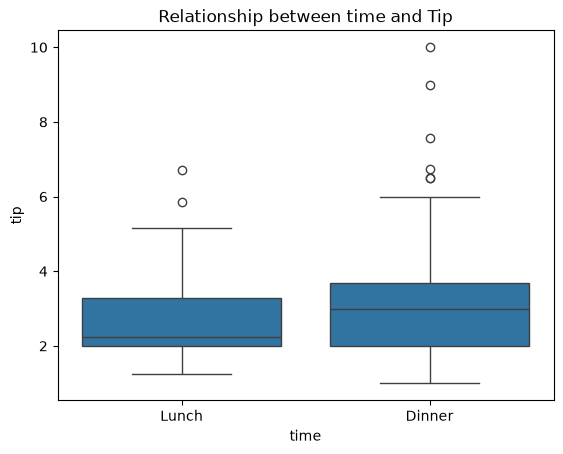

In [8]:
categorical_cols = ['sex', 'smoker', 'day', 'time']

for col in categorical_cols:
    sns.boxplot(data=df, x=col, y='tip')
    plt.title(f"Relationship between {col} and Tip")
    plt.show()

## 2. Data Split & Preprocessing

In [9]:
X = df.drop(columns=['tip'])
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
numeric_features = X.select_dtypes(include=["float64", "int64"]).columns
categorical_features = X.select_dtypes(include=["category", "object"]).columns

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [11]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [12]:
## 3. Modeling & Evaluation Metrics

In [13]:
def regression_metrics(y_true, y_pred, type_data):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Data": type_data,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2_SCORE": r2
    }

In [14]:
def regression_metrics(y_true, y_pred, type_data):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Data": type_data,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2_SCORE": r2
    }

In [15]:
# 1. Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_transformed, y_train)

y_train_pred_linear = linear_model.predict(X_train_transformed)
y_test_pred_linear = linear_model.predict(X_test_transformed)

train_metrics_linear = regression_metrics(y_train, y_train_pred_linear, "Linear Train")
test_metrics_linear = regression_metrics(y_test, y_test_pred_linear, "Linear Test")

In [16]:
# 2. Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_transformed, y_train)

y_train_pred_ridge = ridge_model.predict(X_train_transformed)
y_test_pred_ridge = ridge_model.predict(X_test_transformed)

train_metrics_ridge = regression_metrics(y_train, y_train_pred_ridge, "Ridge Train")
test_metrics_ridge = regression_metrics(y_test, y_test_pred_ridge, "Ridge Test")

In [17]:
# 3. Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_transformed, y_train)

y_train_pred_lasso = lasso_model.predict(X_train_transformed)
y_test_pred_lasso = lasso_model.predict(X_test_transformed)

train_metrics_lasso = regression_metrics(y_train, y_train_pred_lasso, "Lasso Train")
test_metrics_lasso = regression_metrics(y_test, y_test_pred_lasso, "Lasso Test")

In [18]:
## 4. Final Comparison

In [19]:
results = pd.DataFrame([
    train_metrics_linear, test_metrics_linear,
    train_metrics_ridge, test_metrics_ridge,
    train_metrics_lasso, test_metrics_lasso
])

results

,Data,MAE,MSE,RMSE,R2_SCORE
0,Linear Train,0.759965,1.100679,1.049133,0.458249
1,Linear Test,0.667133,0.703357,0.838664,0.437302
2,Ridge Train,0.759684,1.100772,1.049177,0.458203
3,Ridge Test,0.666859,0.700651,0.837049,0.439466
4,Lasso Train,0.777739,1.126875,1.061543,0.445356
5,Lasso Test,0.654809,0.612210,0.782438,0.510221
